# GKP State Preparation: Fixed vs. Optimized Rotation Angles

The Fock-state version of this comparison, applied to a GKP logical state. Two ECD
sequences are optimized to prepare $\ket{0_L}$ from vacuum:

* **frozen** -- all $N+1$ rotation angles held at $\theta_i = \pi/2$ ($3N+1$ parameters);
* **free** -- the angles optimized too ($4N+2$ parameters).

Their Wigner trajectories are then plotted after each ECD, one row each, followed by the
stabilizer diagnostics and an effective Hamiltonian from the BCH product formula.

Three things genuinely differ from the Fock case, and each is checked below rather than
assumed.

**Phase-space orientation is no longer a free gauge.** For a Fock target,
$\beta_i \to \beta_i e^{i\chi}$ rotates the whole trajectory and leaves the fidelity
exactly unchanged, so the two rows had to be gauge-aligned before they could be compared.
A square GKP lattice is only invariant under $\chi = \pi/2$ increments, and even then
$\chi = \pi/2$ is the Fourier/Hadamard action taking $\ket{0_L} \to \ket{+_L}$. Only
$\chi = \pi$ (parity) is a symmetry of $\ket{0_L}$. The lattice therefore pins the
orientation, both runs come out in the same frame, and **no alignment is applied**.

**GKP needs real depth and real amplitude.** $N \approx 12$ ECDs with
$|\beta| \sim \sqrt{\pi}$, against $N = 5$ and $|\beta| \sim 1.4$ for Fock $\ket{2}$. This
pushes the effective Hamiltonian further outside its convergence radius, so the
$H_{\rm eff}$ section is structural rather than quantitative -- stated plainly there.

**$P(n)$ is not the right diagnostic.** A GKP state is not characterized by its photon
number. The stabilizer expectations $\langle \hat S_q\rangle, \langle \hat S_p\rangle$ with
$\hat S_q = \hat D(2\alpha)$, $\hat S_p = \hat D(2i\alpha)$ are used instead, which
separate lattice quality from envelope error.

## Imports

In [7]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

import jax
import jaxquantum as jqt

jax.config.update("jax_enable_x64", True)

from gkp_optimal_control.ecd_symbolic import (
    bloch_axis,
    ecd_propagate,
    ecd_sequence_spec,
    effective_hamiltonian,
    fast_displacement,
    optimize_ecd_fixed_theta,
)
from gkp_optimal_control.gate_optimization import (
    GateBounds,
    OptimizerConfig,
    optimize_gate_sequence,
    sequence_history,
)
from gkp_optimal_control.plotting import plot_wigner, set_plot_style
from gkp_optimal_control.states import gkp_states
from gkp_optimal_control.utils import compute_wigner, to_ket

set_plot_style()
print(f"JAX devices: {jax.devices()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
JAX devices: [CpuDevice(id=0)]


## Configuration

The square-lattice working point: $\alpha = \sqrt{\pi/2}$, $\Delta = 0.40$, which is
$-10\log_{10}\Delta^2 = 8.0$ dB of effective squeezing. `n_fock = 80` is needed because
$\langle n \rangle \approx 3.3$ with a long tail; the truncation check below confirms it.

In [2]:
n_fock = 80
gkp_delta = 0.40
gkp_cutoff = 10
gkp_alpha = np.sqrt(np.pi / 2)
gkp_beta = 1j * np.sqrt(np.pi / 2)

n_gates = 12                  # N, the number of ECDs
theta_fixed = np.pi / 2

vac = jqt.basis(n_fock, 0)
gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
target = gkp_0

# raw vectors for the NumPy layer
vac_np = np.zeros(n_fock, dtype=complex)
vac_np[0] = 1.0
gkp_0_np = np.asarray(to_ket(gkp_0), dtype=complex)
gkp_1_np = np.asarray(to_ket(gkp_1), dtype=complex)

penalty_kw = dict(max_disp=4.0, max_disp_weight=1.0, n_leak=8, leakage_weight=1.0)
bounds = GateBounds(**penalty_kw)
optimizer = OptimizerConfig(
    n_seeds=16,
    n_adam_iters=2000,
    peak_lr=0.03,
    init_disp_scale=1.0,
    polish=True,
    seed=0,
)

# stabilizers and number operator, for the diagnostics
disp = fast_displacement(n_fock)
S_q = disp(2 * gkp_alpha)
S_p = disp(2 * gkp_beta)
a_op = np.diag(np.sqrt(np.arange(1, n_fock)), 1).astype(complex)
n_op = a_op.conj().T @ a_op

# plotting
pair, bound, grid = 0, 6.0, 120
n_show = 6                                  # 12 columns is unwieldy; show a subset
layers = sorted(set(np.linspace(1, n_gates, n_show, dtype=int)))

print(f"GKP |0_L>, delta = {gkp_delta} "
      f"({-10 * np.log10(gkp_delta ** 2):.1f} dB), n_fock = {n_fock}")
print(f"<n> = {np.real(gkp_0_np.conj() @ n_op @ gkp_0_np):.3f},  "
      f"<S_q> = {np.real(gkp_0_np.conj() @ S_q @ gkp_0_np):+.4f},  "
      f"<S_p> = {np.real(gkp_0_np.conj() @ S_p @ gkp_0_np):+.4f}")
print(f"|<0_L|1_L>| = {abs(gkp_0_np.conj() @ gkp_1_np):.2e},  "
      f"tail (top 8 levels) = {np.sum(np.abs(gkp_0_np[-8:]) ** 2):.1e}")
print(f"N = {n_gates} ECDs -> frozen {3 * n_gates + 1} params, "
      f"free {4 * n_gates + 2} params")
print(f"showing layers {layers}")

GKP |0_L>, delta = 0.4 (8.0 dB), n_fock = 80
<n> = 3.297,  <S_q> = +0.6440,  <S_p> = +0.6837
|<0_L|1_L>| = 2.96e-03,  tail (top 8 levels) = 1.4e-08
N = 12 ECDs -> frozen 37 params, free 50 params
showing layers [np.int64(1), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(12)]


## The two optimizations

The free-angle run uses the project's JAX optimizer. The frozen-angle run uses
`optimize_ecd_fixed_theta`, which is multi-start L-BFGS-B on the NumPy layer -- at
$N = 12$ and `n_fock = 80` that costs roughly 15 s per seed, so a cold 64-seed search
would run about half an hour. `n_seeds = 8` below is a compromise; raise it if the
warm start keeps winning.

It is given a **warm start** from the free solution as well: the free $(\phi, \beta)$ with
$\theta$ snapped to $\pi/2$. This is cheap and directly answers "what does the constraint
cost inside the basin the free optimizer found", which is the sharper question. It is a
different question from "what is the best frozen-angle circuit", so cold restarts are run
alongside it and the better of the two is kept. `best_seed = 0` in the summary means the
warm start won.

In [3]:
result_free = optimize_gate_sequence(
    "ecd",
    n_gates,
    vac,
    target,
    n_fock=n_fock,
    qubit_target="ground",
    disp_method="quadrature",
    loss_type="log_infidelity",
    bounds=bounds,
    optimizer=optimizer,
    verbose=True,
)
print()
print(result_free.summary())

gate set : ecd   depth : 12   n_fock : 80
params   : 50   state pairs : 1   reduction : mean
loss     : log_infidelity   disp : quadrature   seeds : 16
--------------------------------------------------------------
Adam (2000 iters x 16 seeds) in 147.3s
  seed fidelities: best 0.996493, median 0.979267, worst 0.949627
  best seed: 0
L-BFGS-B polish: 500 iters in 3.9s  ->  F = 0.997530
--------------------------------------------------------------
Final fidelity : 0.997530   (infidelity 2.470e-03)
Leakage        : 6.059e-10  (top 8 Fock levels)
Peak |disp|    : 2.547
Total time     : 152.1s

gate set        : ecd
n_gates         : 12
n_params        : 50
fidelity        : 0.997530
infidelity      : 2.470e-03
loss            : -6.003367e+00
leakage         : 6.059e-10
best seed       : 0 of 16
seed F spread   : 0.9496 .. 0.9965


In [8]:
result = optimize_ecd_fixed_theta(
    n_gates,
    n_fock,
    # fock_target=None,
    psi_target=gkp_0_np,
    theta=theta_fixed,
    n_seeds=8,                            # ~35 s per seed at N=12, n_fock=80
    seed=0,
    init_disp_scale=1.0,
    params0=result_free.flat_params,      # warm start: free solution snapped to pi/2
    **penalty_kw,
)

gate set        : ecd (theta frozen)
n_gates         : 12
theta_i         : 0.500000 pi  (all 13)
n_params        : 37 free of 50 (13 frozen)
fidelity        : 0.979649
infidelity      : 2.035e-02
loss            : +2.035082e-02
leakage         : 1.634e-29
peak |beta|     : 1.617
best seed       : 6 of 9
seed F spread   : 0.6886 .. 0.9796


In [9]:
thetas = np.asarray(result.params["thetas"])
phis = np.asarray(result.params["phis"])
betas = np.asarray(result.params["betas"])

thetas_free = np.asarray(result_free.params["thetas"])
phis_free = np.asarray(result_free.params["phis"])
betas_free = np.asarray(result_free.params["betas"])

print(f"theta_i/pi, frozen : {np.round(thetas / np.pi, 4)}")
print(f"theta_i/pi, free   : {np.round(thetas_free / np.pi, 4)}")
print()
print(f"F, theta = pi/2    : {result.fidelity:.9f}   (1 - F = {1 - result.fidelity:.3e})")
print(f"F, theta free      : {result_free.fidelity:.9f}   (1 - F = {1 - result_free.fidelity:.3e})")
print(f"the angles buy     : {result_free.fidelity - result.fidelity:+.3e}")
print(f"warm start won?      {result.best_seed == 0}")
print()
print(f"|beta|, frozen     : {np.round(np.abs(betas), 3)}")
print(f"|beta|, free       : {np.round(np.abs(betas_free), 3)}")
print(f"max |beta|         : frozen {np.abs(betas).max():.3f}, "
      f"free {np.abs(betas_free).max():.3f}")

theta_i/pi, frozen : [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
theta_i/pi, free   : [ 0.4987  0.3319  1.1976  0.2088  0.6547  0.9479  0.4336  0.229   0.1507
  0.1242  0.3865  0.518  -0.4905]

F, theta = pi/2    : 0.979649185   (1 - F = 2.035e-02)
F, theta free      : 0.997529579   (1 - F = 2.470e-03)
the angles buy     : +1.788e-02
warm start won?      False

|beta|, frozen     : [1.617 0.518 1.015 0.733 0.969 0.773 0.578 0.872 1.526 0.757 0.858 0.326]
|beta|, free       : [2.529 1.12  1.074 2.547 1.843 2.314 0.892 1.531 1.945 2.084 1.189 0.182]
max |beta|         : frozen 1.617, free 2.547


### Truncation check

Both solutions re-propagated at larger `n_fock`. GKP states have a long Fock tail, so this
matters more here than for a low Fock target: a fidelity that drifts as the truncation
grows was bought from the boundary, not from the physics.

In [10]:
print(f"{'n_fock':>8}  {'F frozen':>12}  {'F free':>12}")
print("-" * 36)
for d in (n_fock, 100, 120):
    g0_d, _ = gkp_states(d, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
    g0_d = np.asarray(to_ket(g0_d), dtype=complex)
    f_fix = abs(np.vdot(g0_d, ecd_propagate(thetas, phis, betas, d)[0])) ** 2
    f_free = abs(np.vdot(g0_d, ecd_propagate(thetas_free, phis_free,
                                             betas_free, d)[0])) ** 2
    print(f"{d:>8}  {f_fix:>12.9f}  {f_free:>12.9f}")

  n_fock      F frozen        F free
------------------------------------
      80   0.979649185   0.997529579
     100   0.979649184   0.997529578
     120   0.979649184   0.997529578


### Rotation is not a free gauge here

For a Fock target this sweep would be flat. For GKP it should only return to the starting
fidelity at $\chi = \pi$, and $\chi = \pi/2$ should split the population between
$\ket{0_L}$ and $\ket{1_L}$ -- that is the square lattice's Fourier symmetry acting as a
logical Hadamard. This is why the trajectories below are plotted unaligned.

In [11]:
print(f"{'chi/pi':>8}  {'|<0_L|psi>|^2':>14}  {'|<1_L|psi>|^2':>14}")
print("-" * 40)
for chi in (0.0, 0.1, 0.25, 0.5, 1.0):
    psi = ecd_propagate(thetas, phis, betas * np.exp(1j * chi * np.pi), n_fock)[0]
    print(f"{chi:>8.2f}  {abs(np.vdot(gkp_0_np, psi)) ** 2:>14.6f}"
          f"  {abs(np.vdot(gkp_1_np, psi)) ** 2:>14.6f}")

  chi/pi   |<0_L|psi>|^2   |<1_L|psi>|^2
----------------------------------------
    0.00        0.979649        0.000238
    0.10        0.289730        0.011644
    0.25        0.300470        0.094643
    0.50        0.492131        0.485811
    1.00        0.979649        0.000238


## Trajectories

A qubit rotation acts as $U_{\rm qubit} \otimes I$ and cannot change the cavity's reduced
state, since $\sum_q (U\psi)_q (U\psi)_q^\dagger = \sum_q \psi_q \psi_q^\dagger$. So the
post-ECD and post-rotation frames give identical Wigner functions; the even indices
$2, 4, \ldots, 2N$ of the history are used.

In [12]:
def cavity_dm(frame):
    # trace the qubit out of an ECD block state -> cavity density matrix
    f = np.asarray(frame)
    rho = np.outer(f[0], f[0].conj()) + np.outer(f[1], f[1].conj())
    return rho / np.real(np.trace(rho))


def trajectory(th, ph, be, d):
    # cavity density matrix right after each ECD gate (no gauge alignment: see above)
    _, hist = ecd_propagate(th, ph, be, d, return_history=True)
    return [cavity_dm(hist[2 * k]) for k in range(1, len(be) + 1)]


# cross-check the NumPy mirror against the project's JAX propagator
hist_jax = sequence_history(result, vac)
ref = [cavity_dm(np.asarray(hist_jax[2 * k])[pair]) for k in range(1, n_gates + 1)]
mine = trajectory(thetas, phis, betas, n_fock)
print("max |rho_numpy - rho_jax| over layers:",
      f"{max(np.abs(m - r).max() for m, r in zip(mine, ref)):.2e}")

traj_fix = trajectory(thetas, phis, betas, n_fock)
traj_free = trajectory(thetas_free, phis_free, betas_free, n_fock)
rows = [
    (rf"frozen $\theta_i=\pi/2$, $F={result.fidelity:.4f}$", traj_fix),
    (rf"free $\theta_i$, $F={result_free.fidelity:.4f}$", traj_free),
]

max |rho_numpy - rho_jax| over layers: 2.66e-15


### Side by side, per-panel scaling

`plot_wigner` normalizes each panel to its own $|W|_{\max}$, so amplitudes are not
comparable across the grid; the shared-scale version follows.

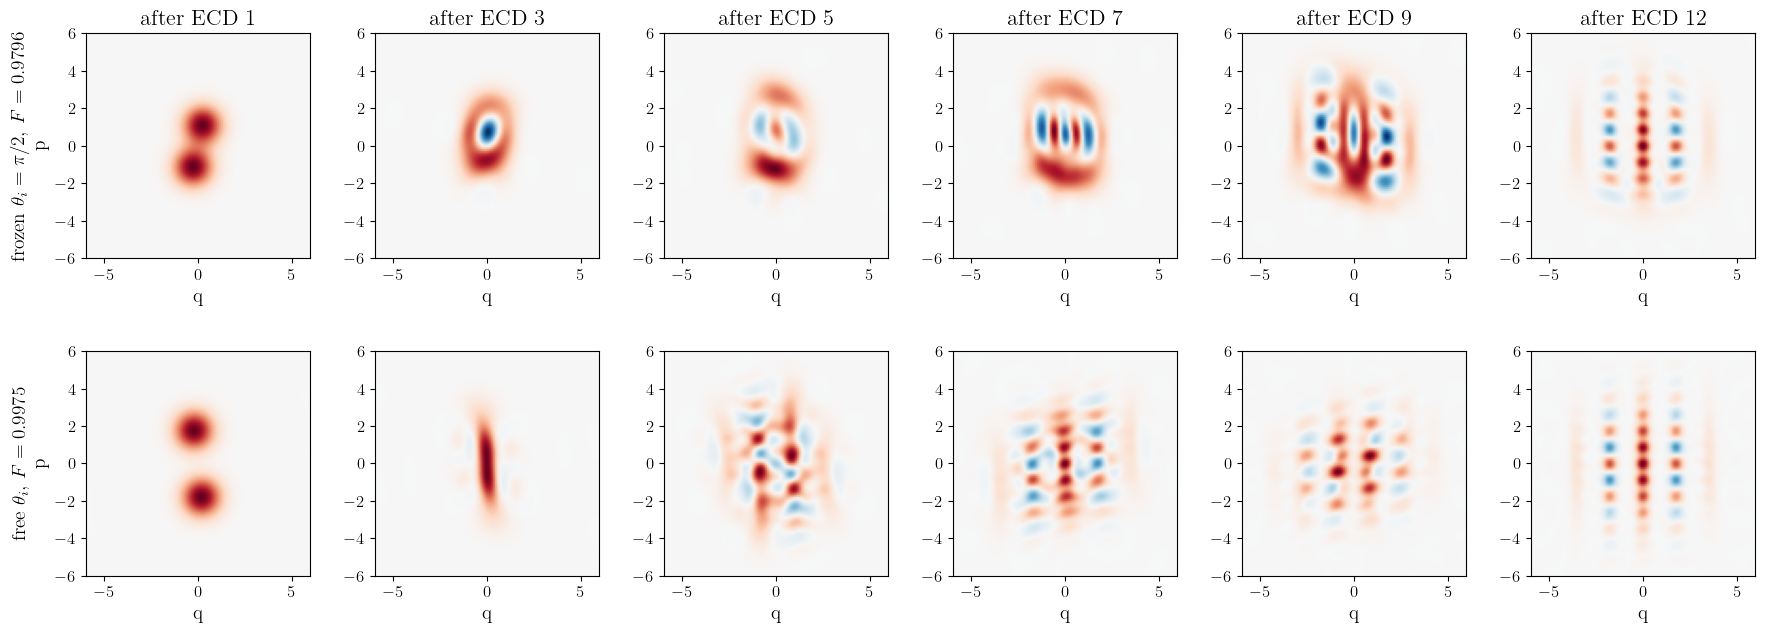

In [13]:
fig, axes = plt.subplots(2, len(layers), figsize=(3.0 * len(layers), 6.8))
for r, (row_label, traj) in enumerate(rows):
    for c, k in enumerate(layers):
        ax = axes[r, c]
        before = set(fig.axes)
        plot_wigner(state=traj[k - 1], x_bound=bound, y_bound=bound, ax=ax,
                    title=(f"after ECD {k}" if r == 0 else None),
                    grid_points=grid, add_colorbar=False)
        # plot_wigner appends a colorbar axes even when add_colorbar=False
        for extra in set(fig.axes) - before:
            extra.set_visible(False)
        ax.set_ylabel(f"{row_label}\np" if c == 0 else "")
fig.tight_layout()
plt.show()

### Side by side, one shared color scale

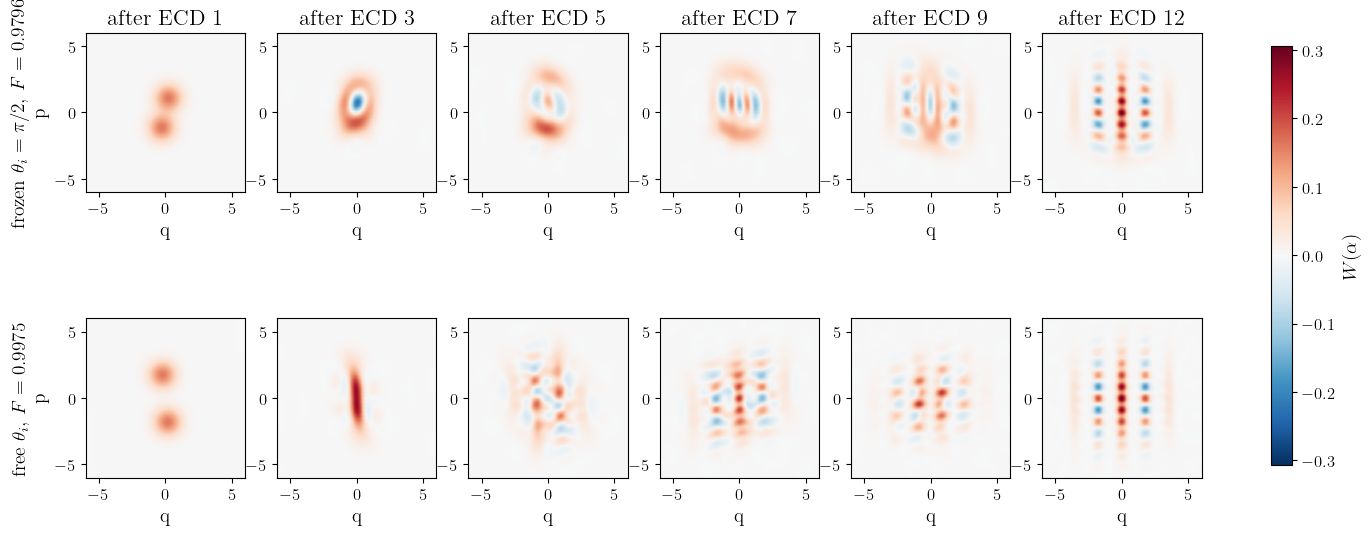

shared |W|max = 0.3063;  per-row ['0.3027', '0.3063']


In [14]:
import matplotlib.colors as mpl_colors

wig_rows = []
for row_label, traj in rows:
    frames = []
    for k in layers:
        xvec, yvec, w = compute_wigner(traj[k - 1], bound, bound, grid)
        frames.append(np.real(np.asarray(w)))
    wig_rows.append((row_label, frames))

wmax = max(np.abs(w).max() for _, frames in wig_rows for w in frames)
norm = mpl_colors.TwoSlopeNorm(vmin=-wmax, vcenter=0.0, vmax=wmax)
x_grid, y_grid = np.meshgrid(np.asarray(xvec), np.asarray(yvec))

fig, axes = plt.subplots(2, len(layers), figsize=(3.0 * len(layers), 6.8))
for r, (row_label, frames) in enumerate(wig_rows):
    for c, w in enumerate(frames):
        ax = axes[r, c]
        mesh = ax.pcolormesh(x_grid, y_grid, w, cmap="RdBu_r", norm=norm,
                             shading="gouraud", rasterized=True)
        ax.set_aspect("equal")
        ax.set_xlabel("q")
        if r == 0:
            ax.set_title(f"after ECD {layers[c]}")
        ax.set_ylabel(f"{row_label}\np" if c == 0 else "")
fig.colorbar(mesh, ax=axes, shrink=0.8, label=r"$W(\alpha)$")
plt.show()
print(f"shared |W|max = {wmax:.4f};  per-row "
      f"{[f'{max(np.abs(w).max() for w in fr):.4f}' for _, fr in wig_rows]}")

### Stabilizer diagnostics

$\langle \hat S_q \rangle$ and $\langle \hat S_p \rangle$ measure how well the lattice has
formed, $\langle n \rangle$ tracks the envelope. Reading them together separates the two
failure modes: a state can have the right energy with a poor lattice, or a clean lattice
with the wrong envelope width. The dashed lines are the target values.

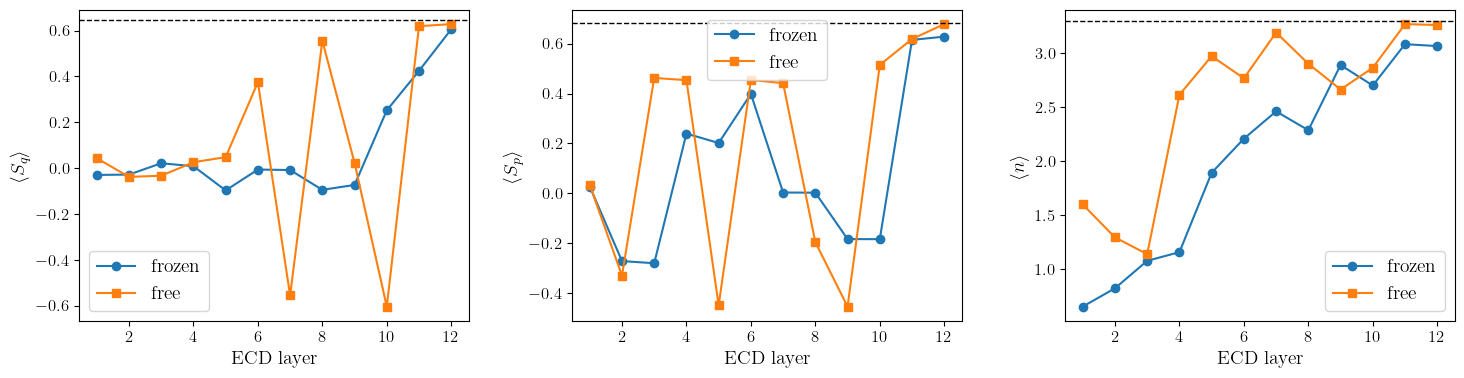

 layer    S_q fix   S_q free    S_p fix   S_p free   <n> fix  <n> free
----------------------------------------------------------------------
     1    -0.0298    +0.0432    +0.0269    +0.0330     0.653     1.599
     2    -0.0283    -0.0383    -0.2719    -0.3304     0.823     1.294
     3    +0.0211    -0.0333    -0.2805    +0.4626     1.077     1.139
     4    +0.0083    +0.0257    +0.2393    +0.4535     1.158     2.615
     5    -0.0973    +0.0477    +0.2016    -0.4493     1.893     2.972
     6    -0.0062    +0.3747    +0.3983    +0.4544     2.208     2.768
     7    -0.0084    -0.5552    +0.0030    +0.4415     2.461     3.191
     8    -0.0948    +0.5558    +0.0024    -0.1961     2.287     2.902
     9    -0.0735    +0.0227    -0.1837    -0.4545     2.890     2.664
    10    +0.2519    -0.6041    -0.1841    +0.5144     2.701     2.865
    11    +0.4242    +0.6191    +0.6149    +0.6185     3.083     3.269
    12    +0.6055    +0.6279    +0.6281    +0.6782     3.066     3.261
target

In [15]:
def diagnostics(traj):
    sq = [np.real(np.trace(rho @ S_q)) for rho in traj]
    sp_ = [np.real(np.trace(rho @ S_p)) for rho in traj]
    nb = [np.real(np.trace(rho @ n_op)) for rho in traj]
    return np.array(sq), np.array(sp_), np.array(nb)


tgt_sq = float(np.real(gkp_0_np.conj() @ S_q @ gkp_0_np))
tgt_sp = float(np.real(gkp_0_np.conj() @ S_p @ gkp_0_np))
tgt_n = float(np.real(gkp_0_np.conj() @ n_op @ gkp_0_np))

ks = np.arange(1, n_gates + 1)
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for (row_label, traj), style in zip(rows, ("-o", "-s")):
    sq, sp_, nb = diagnostics(traj)
    tag = "frozen" if "frozen" in row_label else "free"
    axs[0].plot(ks, sq, style, label=tag)
    axs[1].plot(ks, sp_, style, label=tag)
    axs[2].plot(ks, nb, style, label=tag)
for ax, tgt, lab in zip(axs, (tgt_sq, tgt_sp, tgt_n),
                        (r"$\langle S_q\rangle$", r"$\langle S_p\rangle$",
                         r"$\langle n\rangle$")):
    ax.axhline(tgt, ls="--", c="k", lw=1)
    ax.set_xlabel("ECD layer")
    ax.set_ylabel(lab)
    ax.legend()
fig.tight_layout()
plt.show()

print(f"{'layer':>6}  {'S_q fix':>9}  {'S_q free':>9}  {'S_p fix':>9}"
      f"  {'S_p free':>9}  {'<n> fix':>8}  {'<n> free':>8}")
print("-" * 70)
sq_a, sp_a, nb_a = diagnostics(traj_fix)
sq_b, sp_b, nb_b = diagnostics(traj_free)
for i, k in enumerate(ks):
    print(f"{k:>6}  {sq_a[i]:>+9.4f}  {sq_b[i]:>+9.4f}  {sp_a[i]:>+9.4f}"
          f"  {sp_b[i]:>+9.4f}  {nb_a[i]:>8.3f}  {nb_b[i]:>8.3f}")
print(f"{'target':>6}  {tgt_sq:>+9.4f}  {tgt_sq:>+9.4f}  {tgt_sp:>+9.4f}"
      f"  {tgt_sp:>+9.4f}  {tgt_n:>8.3f}  {tgt_n:>8.3f}")

## Effective Hamiltonian via BCH

Each rotation is conjugated away, leaving every ECD as the exponential of a single
generator along a rotated Bloch axis, and the BCH product formula merges them:

$$U = \mathcal{Q}\prod_{k=N}^{1}
    \exp\!\Big[\tfrac{\hat n_k\cdot\vec\sigma}{2}
    (\beta_k a^\dagger - \bar\beta_k a)\Big]
  = \mathcal{Q}\, e^{-i H_{\rm eff}},
  \qquad H_{\rm eff} = H^{(1)} + H^{(2)} + \cdots$$

graded by powers of the amplitudes. $\mathcal{Q}$ stays factored out because the grading
needs every merged generator to be $O(\beta)$; a leftover $O(1)$ qubit rotation would put
infinitely many terms at each order. Symbolic field-operator algebra is SymBosonKit's;
`bch_product` adds the product formula $\log(e^Ae^B\cdots)$ on top of its `_normal`
primitive.

First the axis geometry. In the Fock-$\ket{2}$ case both optima placed every axis on the
equator, which forced a selection rule (odd orders on $\sigma_x, \sigma_y$, even orders on
$\sigma_z$). There is no reason for GKP to do the same, and the cell below checks rather
than assumes.

In [16]:
spec_fix = ecd_sequence_spec(thetas, phis, betas, theta_exact=sp.pi / 2)
spec_free = ecd_sequence_spec(thetas_free, phis_free, betas_free)

axes_by_tag = {}
for tag, spec in (("frozen", spec_fix), ("free", spec_free)):
    h1 = effective_hamiltonian(spec, order=1)
    vecs = np.array([[float(c) for c in bloch_axis(ax)] for ax in h1.axes])
    axes_by_tag[tag] = vecs
    print(f"{tag:>7}: max |n_z| over the {len(vecs)} axes = "
          f"{np.abs(vecs[:, 2]).max():.3f}")
    print(f"         n_z = {np.round(vecs[:, 2], 3)}")
print()
print("If max |n_z| is not ~0 the axes are off the equator, there is no")
print("odd/even Pauli selection rule, and every order mixes all three Paulis.")

 frozen: max |n_z| over the 12 axes = 0.955
         n_z = [ 0.     0.296  0.955 -0.296 -0.043  0.304  0.355  0.898 -0.348  0.577
 -0.371  0.192]
   free: max |n_z| over the 12 axes = 0.041
         n_z = [ 0.004  0.014  0.009  0.001  0.003 -0.008  0.002  0.008 -0.007  0.012
 -0.007 -0.041]

If max |n_z| is not ~0 the axes are off the equator, there is no
odd/even Pauli selection rule, and every order mixes all three Paulis.


In [17]:
max_order = 3
heffs = {"frozen": effective_hamiltonian(spec_fix, order=max_order),
         "free": effective_hamiltonian(spec_free, order=max_order)}

for tag, h in heffs.items():
    print(f"--- {tag}: sum |coeff| per Pauli, by order ---")
    print(f"{'order':>6}  {'1':>11}  {'x':>11}  {'y':>11}  {'z':>11}   present")
    for k in range(1, max_order + 1):
        wt = {}
        for (pauli, mm, nn), coeff in h.monomials(k).items():
            wt[pauli] = wt.get(pauli, 0.0) + abs(complex(coeff))
        peak = max(wt.values()) if wt else 0.0
        live = [p for p in ("1", "x", "y", "z") if wt.get(p, 0.0) > 1e-4 * peak]
        print(f"{k:>6}  " + "  ".join(f"{wt.get(p, 0.0):11.3e}"
                                      for p in ("1", "x", "y", "z")) + f"   {live}")
    print(f"        Q proportional to identity? {h.q_is_identity()}")
    print()

--- frozen: sum |coeff| per Pauli, by order ---
 order            1            x            y            z   present
     1    0.000e+00    1.785e+00    5.758e-01    3.260e-01   ['x', 'y', 'z']
     2    1.633e-01    2.104e+00    1.936e+00    2.954e+00   ['1', 'x', 'y', 'z']
     3    1.446e+00    5.694e+00    7.652e+00    5.784e+00   ['1', 'x', 'y', 'z']
        Q proportional to identity? False

--- free: sum |coeff| per Pauli, by order ---
 order            1            x            y            z   present
     1    0.000e+00    3.916e+00    2.702e+00    8.930e-02   ['x', 'y', 'z']
     2    1.662e+00    1.295e-01    1.100e-01    1.270e+01   ['1', 'x', 'y', 'z']
     3    1.621e-01    2.159e+01    1.906e+01    3.857e-01   ['1', 'x', 'y', 'z']
        Q proportional to identity? False



### How far the truncation can be trusted

The series is asymptotic: successive ECDs sit on non-parallel axes, the algebra does not
close, and convergence has to be measured rather than assumed. `convergence` compares
$e^{-iH_{\rm eff}}\ket{g,0}$ against the exact ECD product, scanning a scale factor applied
to every $\beta$.

The diagnostic is state-based on purpose. Operator-norm error is misleading because
$H_{\rm eff}$ carries $a^{\dagger m}a^n$ terms whose matrix elements grow with the
truncation, so `max|exp(-iH) - U|` is dominated by Fock levels the state never reaches.

In [18]:
scales = (0.05, 0.1, 0.2, 0.35, 0.5, 1.0)
specs = {"frozen": (thetas, phis, betas, sp.pi / 2),
         "free": (thetas_free, phis_free, betas_free, None)}

for tag, (th, ph, be, texact) in specs.items():
    print(f"--- {tag}: || exp(-i H_eff^(k)) |g,0>  -  U|g,0> || ---")
    print(f"{'scale':>6}  {'max|beta|':>10}  "
          + "".join(f"{'k=' + str(k):>11}" for k in range(1, max_order + 1)))
    print("-" * 52)
    for s in scales:
        h = effective_hamiltonian(
            ecd_sequence_spec(th, ph, np.asarray(be) * s, theta_exact=texact),
            order=max_order)
        conv = h.convergence({}, 48)
        print(f"{s:6.2f}  {np.abs(np.asarray(be) * s).max():10.4f}  "
              + "".join(f"{conv[k]:11.2e}" for k in range(1, max_order + 1)))
    print()

--- frozen: || exp(-i H_eff^(k)) |g,0>  -  U|g,0> || ---
 scale   max|beta|          k=1        k=2        k=3
----------------------------------------------------
  0.05      0.0808     3.40e-03   3.90e-04   3.78e-05
  0.10      0.1617     1.36e-02   3.08e-03   6.01e-04
  0.20      0.3233     5.39e-02   2.32e-02   9.34e-03
  0.35      0.5658     1.59e-01   1.06e-01   7.77e-02
  0.50      0.8083     3.00e-01   2.43e-01   2.32e-01
  1.00      1.6165     7.93e-01   7.52e-01   8.95e-01

--- free: || exp(-i H_eff^(k)) |g,0>  -  U|g,0> || ---
 scale   max|beta|          k=1        k=2        k=3
----------------------------------------------------
  0.05      0.1274     1.38e-02   3.33e-04   3.66e-05
  0.10      0.2547     5.49e-02   2.80e-03   5.86e-04
  0.20      0.5094     2.18e-01   2.65e-02   9.21e-03
  0.35      0.8915     6.49e-01   1.76e-01   8.94e-02
  0.50      1.2736     1.20e+00   4.67e-01   3.74e-01
  1.00      2.5472     1.80e+00   1.75e+00   1.74e+00



## Reading the comparison

The fidelity difference is the only number that settles whether the angles earned their
keep, and `best_seed` says whether the frozen solution came from the warm start (same basin
as the free one, so the difference is the cost of the constraint) or from a cold restart
(a different basin, so it is a comparison of two searches).

The stabilizer panels are where the trajectories become legible. Both runs build
$\langle S_q \rangle, \langle S_p \rangle$ up from zero, and the layer at which each
stabilizer starts to rise says where in the circuit that quadrature's lattice is being
formed -- information the fidelity alone hides.

On $H_{\rm eff}$: at $\max|\beta| \sim 2$-$3$ the expansion is far outside its useful
range, and the convergence table shows the error at order unity for scale $1.0$. Read it as
a structural statement -- which Paulis appear, what operator content each order carries,
whether the axes are equatorial -- not as a quantitative generator for these circuits. To
get one that converges, the lever is amplitude rather than order: `max_disp` near $0.5$ with
many more ECDs.

Both Wigner rows show the qubit-*traced* cavity state, which is right mid-sequence but is
not the prepared state at the end: the figure of merit is the $\ket{g}$ block alone, and
the two differ by exactly the residual entanglement.